In [1]:
# Import core libraries for data handling, file paths, maths, and statistics
import pandas as pd
from pathlib import Path
import numpy as np
from scipy.stats import stats
from scipy.stats import t
from scipy.stats import ttest_ind

In [2]:
# Load the CSV dataset into a pandas DataFrame
df = pd.read_csv(str(Path("E:\\Datasets\\ids.csv")))

In [3]:
# Display the last 50 records 
df.tail(50)

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
488065,488065,53,70591,2,2,66,194,33,33,33.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration
488066,488066,443,5572560,8,6,386,5205,205,0,48.250000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488067,488067,3013,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488068,488068,53,122130,2,2,80,272,40,40,40.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488069,488069,53,98106274,2,2,114,211,58,56,57.000000,...,20,30943.00000,0.00000,30943,30943,9.800000e+07,0.00000,98000000,98000000,Infiltration
488070,488070,53,506,1,1,53,113,53,53,53.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488071,488071,53,3957631,2,2,120,260,79,41,60.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488072,488072,9102,2,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488073,488073,2135,111,2,2,4,12,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488074,488074,1048,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration


In [4]:
# Define the 16 columns specified for analysis
columns = ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 
           'Total Backward Packets', 'Total Length of Fwd Packets', 
           'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 
           'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 
           'Packet Length Mean', 'Packet Length Std', 'Average Packet Size', 
           'Active Mean', 'Idle Mean', 'Label']

In [5]:
# Create a new DataFrame with only the 16 selected columns
df1 = df[columns].copy()

In [6]:
# Confirm the filtered DataFrame looks correct by checking the last 50 rows
df1.tail(50)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
488065,53,70591,2,2,66,194,33.000000,97.000000,3.683189e+03,56.664447,58.600000,35.054244,73.250000,0.00000,0.000000e+00,Infiltration
488066,443,5572560,8,6,386,5205,48.250000,867.500000,1.003309e+03,2.512310,372.733333,675.557703,399.357143,0.00000,0.000000e+00,BENIGN
488067,3013,49,2,0,4,0,2.000000,0.000000,8.163265e+04,40816.326530,2.000000,0.000000,3.000000,0.00000,0.000000e+00,BENIGN
488068,53,122130,2,2,80,272,40.000000,136.000000,2.882175e+03,32.751986,78.400000,52.581366,98.000000,0.00000,0.000000e+00,BENIGN
488069,53,98106274,2,2,114,211,57.000000,105.500000,3.312734e+00,0.040772,76.200000,35.737935,95.250000,30943.00000,9.800000e+07,Infiltration
488070,53,506,1,1,53,113,53.000000,113.000000,3.280632e+05,3952.569170,73.000000,34.641016,109.500000,0.00000,0.000000e+00,BENIGN
488071,53,3957631,2,2,120,260,60.000000,130.000000,9.601704e+01,1.010706,91.800000,44.013634,114.750000,0.00000,0.000000e+00,BENIGN
488072,9102,2,2,0,4,0,2.000000,0.000000,2.000000e+06,1000000.000000,2.000000,0.000000,3.000000,0.00000,0.000000e+00,BENIGN
488073,2135,111,2,2,4,12,2.000000,6.000000,1.441441e+05,36036.036040,3.600000,2.190890,4.500000,0.00000,0.000000e+00,BENIGN
488074,1048,49,2,0,4,0,2.000000,0.000000,8.163265e+04,40816.326530,2.000000,0.000000,3.000000,0.00000,0.000000e+00,Infiltration


In [7]:
# Extended tail check to verify the data structure
df1.tail(100)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
488015,563,49,2,0,4,0,2.000000,0.000000,8.163265e+04,40816.326530,2.000000,0.000000,3.000,0.00000,0.000000e+00,BENIGN
488016,58044,56,1,1,6,6,6.000000,6.000000,2.142857e+05,35714.285710,6.000000,0.000000,9.000,0.00000,0.000000e+00,Infiltration
488017,53,60813,2,2,64,142,32.000000,71.000000,3.387434e+03,65.775410,47.600000,21.361180,59.500,0.00000,0.000000e+00,Infiltration
488018,80,115388796,17,15,942,1598,55.411765,106.533333,2.201254e+01,0.277323,76.969697,212.157884,79.375,50883.90909,9.996107e+06,BENIGN
488019,80,96871,1,1,0,0,0.000000,0.000000,0.000000e+00,20.646014,0.000000,0.000000,0.000,0.00000,0.000000e+00,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488110,53,238,2,2,86,228,43.000000,114.000000,1.319328e+06,16806.722690,71.400000,38.888302,89.250,0.00000,0.000000e+00,BENIGN
488111,8899,3,2,0,4,0,2.000000,0.000000,1.333333e+06,666666.666700,2.000000,0.000000,3.000,0.00000,0.000000e+00,Infiltration
488112,53,250,2,2,82,206,41.000000,103.000000,1.152000e+06,16000.000000,65.800000,33.958799,82.250,0.00000,0.000000e+00,BENIGN
488113,53,70581019,2,2,117,231,58.500000,115.500000,4.930504e+00,0.056672,82.800000,30.817203,103.500,41306.00000,7.030000e+07,BENIGN


In [8]:
# Count missing values in each column 
df1.isnull().sum()

Destination Port                0
Flow Duration                   0
Total Fwd Packets               0
Total Backward Packets          0
Total Length of Fwd Packets     0
Total Length of Bwd Packets     0
Fwd Packet Length Mean          0
Bwd Packet Length Mean          0
Flow Bytes/s                   36
Flow Packets/s                  0
Packet Length Mean              0
Packet Length Std               0
Average Packet Size             0
Active Mean                     0
Idle Mean                       0
Label                           0
dtype: int64

In [9]:
# Drop all rows containing NaN values to clean the dataset
df1 = df1.dropna()

In [10]:
# Re-check to confirm all missing values have been removed successfully
df1.isnull().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Mean         0
Bwd Packet Length Mean         0
Flow Bytes/s                   0
Flow Packets/s                 0
Packet Length Mean             0
Packet Length Std              0
Average Packet Size            0
Active Mean                    0
Idle Mean                      0
Label                          0
dtype: int64

In [11]:
# Count total number of duplicate rows and store the result
count = df1.duplicated().sum()

In [12]:
# Show a True/False Series indicating which rows are duplicates
df1.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
488110     True
488111     True
488112    False
488113    False
488114    False
Length: 488079, dtype: bool

In [13]:
# Display all duplicate rows in full
df1[df1.duplicated()]

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
208,8084,3,2,0,4,0,2.0,0.0,1.333333e+06,666666.666700,2.000000,0.000000,3.00,0.0,0.0,BENIGN
292,443,3,2,0,12,0,6.0,0.0,4.000000e+06,666666.666700,6.000000,0.000000,9.00,0.0,0.0,BENIGN
778,443,4,2,0,12,0,6.0,0.0,3.000000e+06,500000.000000,6.000000,0.000000,9.00,0.0,0.0,Infiltration
949,443,49,2,0,12,0,6.0,0.0,2.448980e+05,40816.326530,6.000000,0.000000,9.00,0.0,0.0,Infiltration
1102,443,3,2,0,12,0,6.0,0.0,4.000000e+06,666666.666700,6.000000,0.000000,9.00,0.0,0.0,Infiltration
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488100,53,206842,1,1,48,142,48.0,142.0,9.185755e+02,9.669216,79.333333,54.270925,119.00,0.0,0.0,Infiltration
488101,8402,49,2,0,4,0,2.0,0.0,8.163265e+04,40816.326530,2.000000,0.000000,3.00,0.0,0.0,Infiltration
488102,21,72,1,2,6,12,6.0,6.0,2.500000e+05,41666.666670,6.000000,0.000000,8.00,0.0,0.0,BENIGN
488110,53,238,2,2,86,228,43.0,114.0,1.319328e+06,16806.722690,71.400000,38.888302,89.25,0.0,0.0,BENIGN


In [14]:
# Print the total number of duplicate records found in the dataset
df1.duplicated().sum()

np.int64(139389)

In [15]:
# Display the total number of columns in the filtered DataFrame
df1.shape[1]

16

In [16]:
# List all column names to verify the correct features are present
df1.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
       'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
       'Packet Length Mean', 'Packet Length Std', 'Average Packet Size',
       'Active Mean', 'Idle Mean', 'Label'],
      dtype='object')

In [17]:
# Inspect the Label column to see its current raw values 
df1['Label']

0               BENIGN
1         Infiltration
2               BENIGN
3               BENIGN
4               BENIGN
              ...     
488110          BENIGN
488111    Infiltration
488112          BENIGN
488113          BENIGN
488114          BENIGN
Name: Label, Length: 488079, dtype: object

In [34]:
# Rename Label values to human-readable categories for clarity
df1['Label'].replace({'BENIGN' : 'Normal Traffic', 'Infiltration' : 'Attack'})

0         Normal Traffic
1                 Attack
2         Normal Traffic
3         Normal Traffic
4         Normal Traffic
               ...      
488110    Normal Traffic
488111            Attack
488112    Normal Traffic
488113    Normal Traffic
488114    Normal Traffic
Name: Label, Length: 488079, dtype: object

In [19]:
# Compute sum, mean, std deviation, skewness, and kurtosis for two key features
df1[['Flow Duration','Packet Length Mean']].agg(['sum','mean','std','skew','kurt'])

,Flow Duration,Packet Length Mean
sum,4.364853e+12,4.175763e+07
mean,8.942923e+06,8.555506e+01
std,2.748182e+07,1.738725e+02
skew,3.250874e+00,4.935766e+00
kurt,9.246791e+00,3.461051e+01


In [20]:
# Select only numeric columns and compute the full Pearson correlation matrix
numeric_df1 = df1.select_dtypes(include=['number'])
corr = numeric_df1.corr()
print(corr)

                             Destination Port  Flow Duration  \
Destination Port                     1.000000      -0.145250   
Flow Duration                       -0.145250       1.000000   
Total Fwd Packets                   -0.025711       0.124344   
Total Backward Packets              -0.024028       0.100836   
Total Length of Fwd Packets          0.004815       0.032044   
Total Length of Bwd Packets         -0.015581       0.063465   
Fwd Packet Length Mean               0.005199       0.114950   
Bwd Packet Length Mean              -0.217264       0.351037   
Flow Bytes/s                         0.063783      -0.018884   
Flow Packets/s                       0.214177      -0.113359   
Packet Length Mean                  -0.118523       0.324827   
Packet Length Std                   -0.156795       0.465984   
Average Packet Size                 -0.127719       0.303080   
Active Mean                         -0.051505       0.204673   
Idle Mean                           -0.1

In [21]:
# Flatten the correlation matrix and extract the top 5 feature pairs
corr_pairs = corr.unstack()
corr_pairs = corr_pairs[corr_pairs != 1]
corr_pairs = corr_pairs.drop_duplicates()
corr_pairs = corr_pairs.sort_values(ascending=False)
print(corr_pairs.head(5))

Packet Length Mean      Average Packet Size            0.995068
Total Backward Packets  Total Length of Bwd Packets    0.961480
Total Fwd Packets       Total Backward Packets         0.949848
                        Total Length of Bwd Packets    0.920007
Packet Length Mean      Packet Length Std              0.887792
dtype: float64


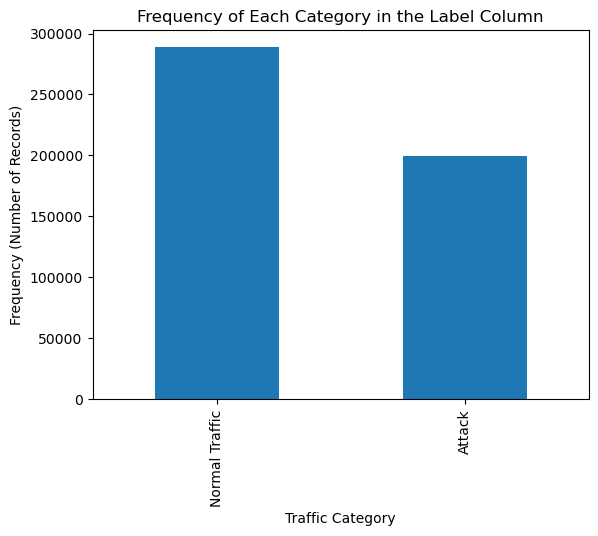

In [22]:
# Apply label renaming and plot a bar chart showing class frequency
import matplotlib.pyplot as plt
df1['Label'] = df1['Label'].replace({'BENIGN': 'Normal Traffic', 'Infiltration': 'Attack'})
df1['Label'].value_counts().plot(kind='bar')
plt.title("Frequency of Each Category in the Label Column")
plt.xlabel("Traffic Category")
plt.ylabel("Frequency (Number of Records)")
plt.show()

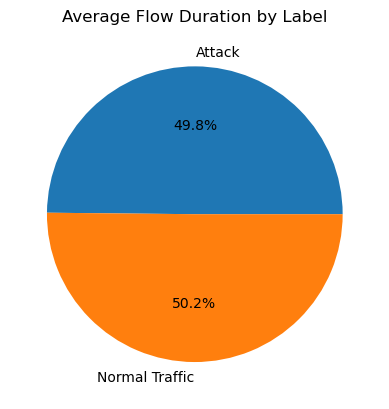

In [23]:
# Compare average Flow Duration between Normal Traffic and Attack using a pie chart
df1.groupby('Label')['Flow Duration'].mean().plot(kind='pie', autopct='%1.1f%%')
plt.title("Average Flow Duration by Label")
plt.ylabel("")
plt.show()

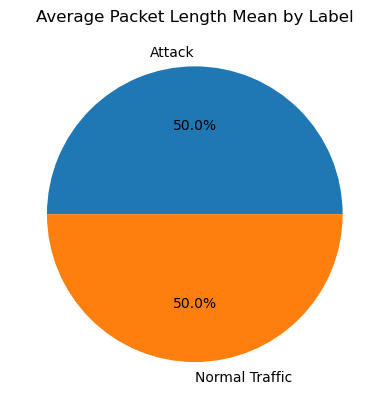

In [24]:
# Compare average Packet Length Mean between Normal Traffic and Attack using a pie chart
df1.groupby('Label')['Packet Length Mean'].mean().plot(kind='pie', autopct='%1.1f%%')
plt.title("Average Packet Length Mean by Label")
plt.ylabel("")
plt.show()

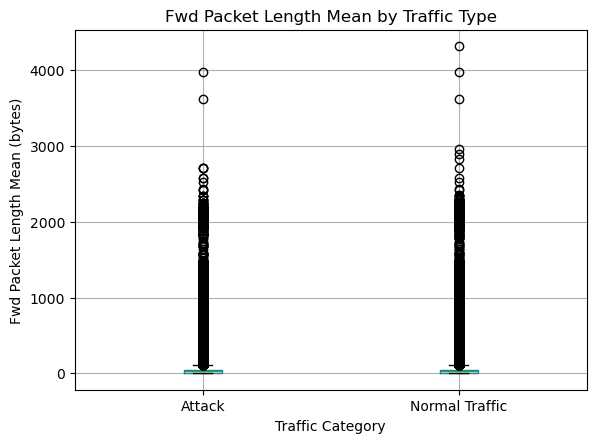

In [25]:
# Plot the distribution of Fwd Packet Length Mean for each traffic class
df1.boxplot(column='Fwd Packet Length Mean', by='Label')
plt.title("Fwd Packet Length Mean by Traffic Type")
plt.suptitle("")
plt.xlabel("Traffic Category")
plt.ylabel("Fwd Packet Length Mean (bytes)")
plt.show()

In [35]:
# Separate Flow Duration values by class
normal = df1.loc[df1['Label'] == 'Normal Traffic', 'Flow Duration']
attack = df1.loc[df1['Label'] == 'Attack', 'Flow Duration']

# Get sample sizes, means, and standard deviations for each group
n1 = normal.shape[0]
n2 = attack.shape[0]
m1 = np.mean(normal)
m2 = np.mean(attack)
s1 = np.std(normal, ddof=1)
s2 = np.std(attack, ddof=1)

# Welch's degrees of freedom formula
df_deg = n1 + n2 - 2

# Compute the Welch t-score manually
t_score = (m1 - m2) / np.sqrt(((s1**2) / n1) + ((s2**2) / n2))
print("t-score=", t_score)
print(df_deg)

# Find the critical value at alpha = 0.05 (two-tailed)
alpha = 0.05
critical_value = t.ppf(1 - alpha/2, df_deg)
print(critical_value)

# Make a decision based on the t-score vs critical value
if t_score > critical_value:
    print("Reject Null Hypothesis. Conclusion. Attack will make difference on Traffic Flow Duration")
else:
    print("Failed to reject Null Hypothesis. Conclusion. Attack will not make difference on Traffic Flow Duration")

t-score= 0.7166329663218244
488077
1.9599688449965251
Failed to reject Null Hypothesis. Conclusion. Attack will not make difference on Traffic Flow Duration
